In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from umapplot import plot_umap
from cellplot import CellPlot
import numpy as np

slidenum = 3
celllist = pd.read_csv(f'./data/{slidenum}_celllist.csv').to_dict(orient='records') 
umap_result = pd.read_csv(f'./data/{slidenum}_umap_result.csv')

plot = CellPlot()
plot.data_all = celllist

/tmp/ipykernel_4962/527875390.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


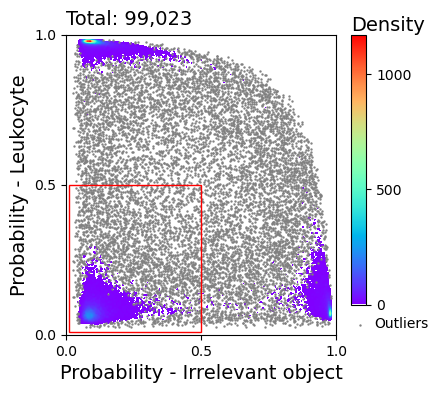

In [2]:
# Leukocyte - Debris Plot
xaxis = 'Debris_prob'
yaxis = 'Leu_prob'
xlabel = 'Probability - Irrelevant object'
ylabel = 'Probability - Leukocyte'

fig, ax = plot.scatter(xaxis, yaxis, title='', xlabel=xlabel, ylabel=ylabel, xlim=(0,1), ylim=(0,1), figsize=(3,3), fontsize=10)
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
xmin, xmax, ymin, ymax = 0.01, 0.5, 0.01, 0.5
rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1,edgecolor='r', facecolor='none')
ax.add_patch(rect)
fig.tight_layout()

gate1 = [cell for cell in celllist if xmin <= cell[xaxis] <= xmax and ymin <= cell[yaxis] <= ymax]

/tmp/ipykernel_4962/1918586006.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


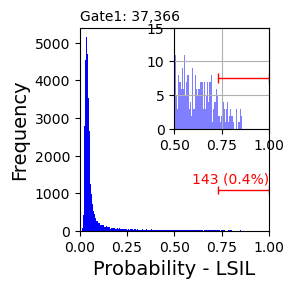

/tmp/ipykernel_4962/1918586006.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


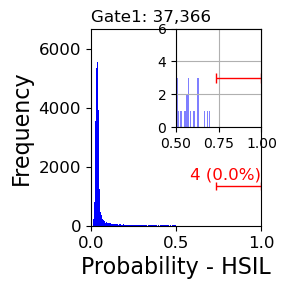

In [3]:
def scaled_sigmoid(x, k=1, s=0, a=1):
    return a / (a + np.exp(-k * (x - s)))

thresh_ssLSIL = scaled_sigmoid(1)
thresh_ssHSIL = scaled_sigmoid(1)

# LSIL histogram
xaxis = 'LSIL_prob'
xlabel = 'Probability - LSIL'
fig, ax = plot.hist(xaxis, gate1, title='', xlim=(0, 1), figsize=(3, 3), fontsize=10, xlabel=xlabel, population_name='Gate1')
plot.gate_linear((thresh_ssLSIL,1), color = 'red', draw_text = True, name = '', fontsize=10, linepos=0.2)
fig.tight_layout()
#fig.savefig(f'figs/plot_{slidenum:03d}_LSIL.png', bbox_inches='tight')
plt.show()

# HSIL histogram
xaxis = 'HSIL_prob'
xlabel = 'Probability - HSIL'
fig, ax = plot.hist(xaxis, gate1, title='', xlim=(0, 1), figsize=(3, 3), fontsize=12, xlabel=xlabel, population_name='Gate1')
plot.gate_linear((thresh_ssHSIL,1), color = 'red', draw_text = True, name = '', fontsize=12, linepos=0.2)
fig.tight_layout()
#fig.savefig(f'figs/plot_{slidenum:03d}_HSIL.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_4962/3523505835.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


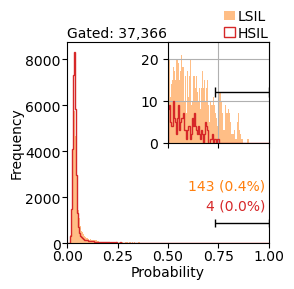

In [4]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------------------------------------------------
# LSIL / HSIL overlay histogram (with inset)
# ------------------------------------------------------------
lsil = [d['LSIL_prob'] for d in gate1]
hsil = [d['HSIL_prob'] for d in gate1]

bins = np.linspace(0.0, 1.0, 201)

fig, ax = plt.subplots(figsize=(3, 3))

ax.hist(
    lsil,
    bins=bins,
    histtype='stepfilled',
    alpha=0.5,
    linewidth=1.0,
    label='LSIL',
    color='tab:orange',
)
ax.hist(
    hsil,
    bins=bins,
    histtype='step',
    linewidth=1.0,
    label='HSIL',
    color='tab:red',
)

ax.set_xlim(0, 1)
ax.set_xlabel('Probability', fontsize=10, labelpad=1)
ax.set_ylabel('Frequency', fontsize=10, labelpad=1)
ax.tick_params(labelsize=10, pad=1)
legend = ax.legend(
    fontsize=10,
    ncol=1,
    frameon=False,
    loc='lower right',
    bbox_to_anchor=(1.0, 1.01),
    borderaxespad=0.0,

    labelspacing=0.2,   
    columnspacing=0.3,  
    borderpad=0.0,      
    handlelength=0.8,   
    handletextpad=0.2,  
)

ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right', borderpad=0)
ax_inset.margins(0)

lsil_in = [v for v in lsil if v > 0.5]
hsil_in = [v for v in hsil if v > 0.5]

ax_inset.hist(
    lsil_in,
    bins=bins,
    histtype='stepfilled',
    alpha=0.5,
    linewidth=1.0,
    color='tab:orange',
)
ax_inset.hist(
    hsil_in,
    bins=bins,
    histtype='step',
    linewidth=1.0,
    color='tab:red',
)

ax_inset.set_xlim(0.5, 1.0)
ax_inset.set_ylim(0, 24)
ax_inset.grid(True)
ax_inset.tick_params(labelbottom=False)

textstr = f'Gated: {len(lsil):,}'
ax.text(
    0,
    1.01,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='left',
)

plot.fig = fig
plot.ax = ax
plot.ax_inset = ax_inset

color='black'
linepos=0.1
threshold = (thresh_ssLSIL, 1)
y_middle = (1-linepos) * ax.get_ylim()[0] + linepos * ax.get_ylim()[1] 
ax.hlines(y=y_middle, xmin=threshold[0], xmax=threshold[1], color=color, linestyle='-', linewidth=1)
ax.vlines(x=threshold[0], ymin=y_middle*0.8, ymax=y_middle*1.2, color=color, linestyle='-', linewidth=1)
ax.vlines(x=threshold[1], ymin=y_middle*0.8, ymax=y_middle*1.2, color=color, linestyle='-', linewidth=1)

y_middle_inset = 0.5 * ax_inset.get_ylim()[0] + 0.5 * ax_inset.get_ylim()[1]  # 子プロットのY軸の中央
ax_inset.hlines(y=y_middle_inset, xmin=threshold[0], xmax=threshold[1], color=color, linestyle='-', linewidth=1)
ax_inset.vlines(x=threshold[0], ymin=y_middle_inset*0.9, ymax=y_middle_inset*1.1, color=color, linestyle='-', linewidth=1)
ax_inset.vlines(x=threshold[1], ymin=y_middle_inset*0.9, ymax=y_middle_inset*1.1, color=color, linestyle='-', linewidth=1)

thr_low, thr_high = threshold

n_lsil = np.sum(thr_low <= lsil)
n_hsil = np.sum(thr_low <= hsil)
total = len(lsil)

pct_lsil = n_lsil / total * 100
pct_hsil = n_hsil / total * 100

tx = ax.get_xaxis_transform()

ax.text(0.98, 0.25,
        f'{n_lsil:,} ({pct_lsil:.1f}%)',
        transform=tx, fontsize=10, color='tab:orange',
        ha='right', va='bottom')

ax.text(0.98, 0.15,
        f'{n_hsil:,} ({pct_hsil:.1f}%)',
        transform=tx, fontsize=10, color='tab:red',
        ha='right', va='bottom')


fig.tight_layout()
plt.show()


/workspaces/cyboscan-paper-private/downstream_analysis/umap_plot/umapplot.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=class_to_color[cls], label=class_to_label[cls], s=30)


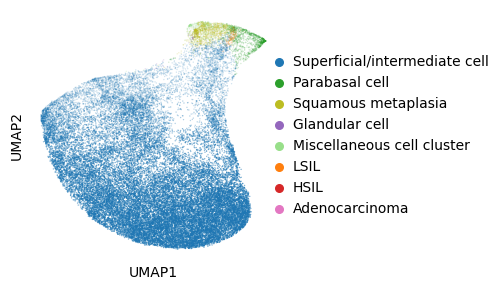

In [5]:
fig, ax = plt.subplots(figsize=(5,3))
plot_umap(ax, umap_result, show_legend=True, show_axis=False, show_axis_label=True)
